# Sensorimotor EEG ERD Analysis

Decoding motor intent from sensorimotor EEG using spectral and time–frequency analysis.

**Goal:** Quantify event-related desynchronization (ERD) in the mu (8–12 Hz) and beta (13–30 Hz) bands over sensorimotor cortex (C3/Cz/C4) during motor task events.

#
## Load Dataset (EEGBCI / PhysioNet)

We use the PhysioNet EEG Motor Movement/Imagery dataset via MNE's EEGBCI loader.  
The dataset is stored in EDF format (standard EEG file format). Event markers include:

- **T0**: rest
- **T1, T2**: task classes (depends on run; commonly left vs right motor imagery)

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import mne
import re
from mne.datasets import eegbci
from mne.io import read_raw_edf

runs = [6]  # common motor imagery run

# Load all 3 subjects
subjects = [1, 2, 3]
all_files = []
for s in subjects:
    all_files.append(eegbci.load_data(s, runs))

files = all_files[0]
raw = read_raw_edf(files[0], preload=True, verbose=False)

raw

<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MB, data loaded>

## Basic Inspection / Exploratory Visualization

We inspect metadata and visualize a short segment of raw EEG to confirm signal quality.

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: 3 items (dict)
>
Number of channels: 64
First 15 channels: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.']


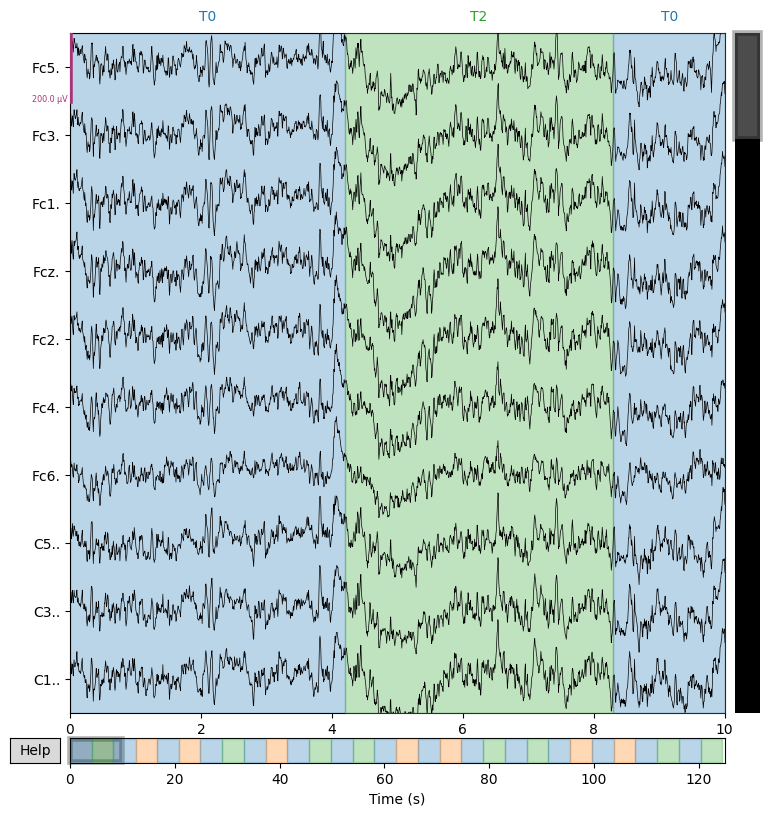

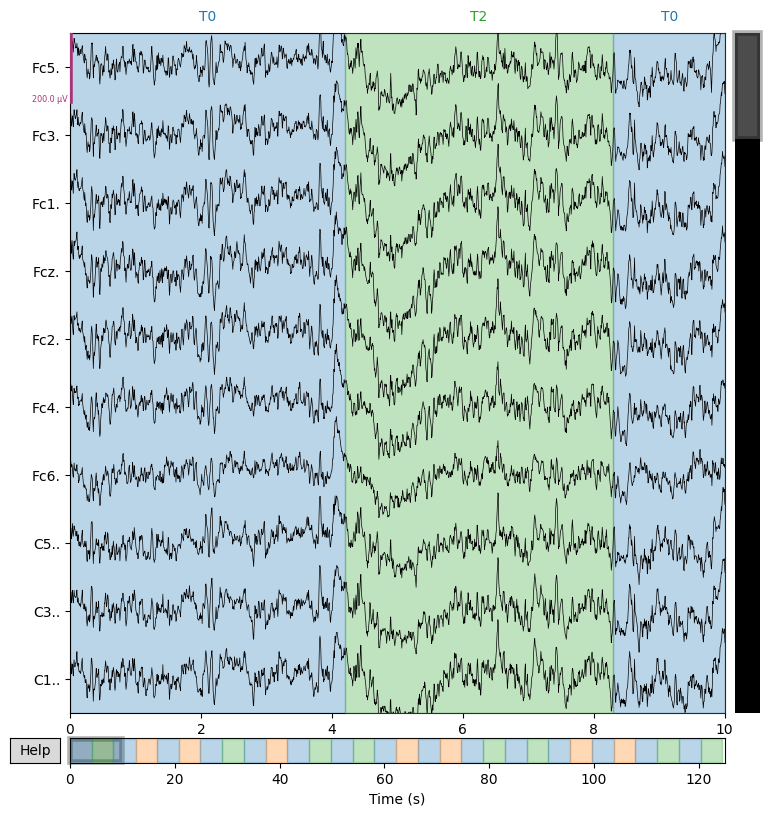

In [41]:
print(raw.info)
print("Number of channels:", len(raw.ch_names))
print("First 15 channels:", raw.ch_names[:15])

raw.plot(n_channels=10, duration=10, scalings=dict(eeg=100e-6), butterfly=False)

## Channel Name Cleanup + Montage

Some channel names in EEGBCI include punctuation (e.g., `C3.`).  
We remove dots/spaces so channels match standard 10–20 naming, then attach a 10–20 montage for scalp locations.

In [42]:
raw.rename_channels(lambda ch: re.sub(r'[\.\s]', '', ch))
raw.set_montage("standard_1020", on_missing="ignore")

# confirm ROI channels exist
roi = ["C3", "Cz", "C4"]
print("ROI present:", {ch: (ch in raw.ch_names) for ch in roi})

ROI present: {'C3': True, 'Cz': True, 'C4': True}


## Preprocessing: Bandpass Filter (1–40 Hz)

We bandpass filter to remove slow drifts (<1 Hz) and high-frequency noise (>40 Hz), while preserving mu and beta rhythms.

In [43]:
raw_filt = raw.copy().filter(l_freq=1.0, h_freq=40.0)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.1s finished


## Event Extraction

We extract events from annotations. The EEGBCI dataset typically uses T0/T1/T2 markers.

In [44]:
events, event_id = mne.events_from_annotations(raw_filt)
print("event_id mapping:", event_id)
events[:10]

Used Annotations descriptions: ['T0', 'T1', 'T2']
event_id mapping: {'T0': 1, 'T1': 2, 'T2': 3}


array([[   0,    0,    1],
       [ 672,    0,    3],
       [1328,    0,    1],
       [2000,    0,    2],
       [2656,    0,    1],
       [3328,    0,    2],
       [3984,    0,    1],
       [4656,    0,    3],
       [5312,    0,    1],
       [5984,    0,    2]])

## Epoching Around Events

We segment the continuous EEG into epochs centered on each event.  
We use a baseline window of **-2 to -1 seconds** before the event for normalization.

In [45]:
epochs = mne.Epochs(
    raw_filt,
    events,
    event_id=event_id,
    tmin=-2.0,
    tmax=2.0,
    baseline=(-2.0, -1.0),
    picks="eeg",
    preload=True
)

epochs_T0 = epochs["T0"]
epochs_T1 = epochs["T1"]
epochs_T2 = epochs["T2"]
epochs_task = mne.concatenate_epochs([epochs_T1, epochs_T2])

print("Epoch counts:", len(epochs_T0), len(epochs_T1), len(epochs_T2))

Not setting metadata
30 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
1 bad epochs dropped
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)
Epoch counts: 14 7 8


/var/folders/31/bs4jdkrd0c1cpymp49c91hvr0000gn/T/ipykernel_4568/3460007673.py:15: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_task = mne.concatenate_epochs([epochs_T1, epochs_T2])


## Spectral Analysis: PSD (Welch)

We compute power spectral density (PSD) using Welch’s method to compare oscillatory power across frequencies.

Effective window size : 4.006 (s)
Effective window size : 4.006 (s)


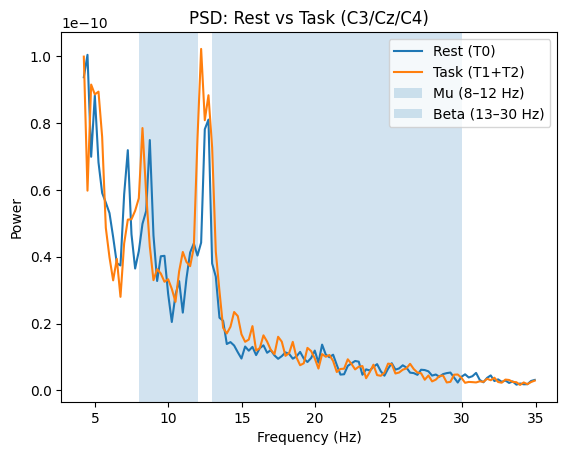

In [46]:
psd_rest = epochs_T0.copy().pick(roi).compute_psd(method="welch", fmin=4, fmax=35)
psd_task = epochs_task.copy().pick(roi).compute_psd(method="welch", fmin=4, fmax=35)

freqs = psd_rest.freqs
rest_mean = psd_rest.get_data().mean(axis=(0, 1))  # avg over epochs + channels
task_mean = psd_task.get_data().mean(axis=(0, 1))

plt.figure()
plt.plot(freqs, rest_mean, label="Rest (T0)")
plt.plot(freqs, task_mean, label="Task (T1+T2)")
plt.axvspan(8, 12, alpha=0.2, label="Mu (8–12 Hz)")
plt.axvspan(13, 30, alpha=0.2, label="Beta (13–30 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("PSD: Rest vs Task (C3/Cz/C4)")
plt.legend()
plt.show()

## Lateralization: C3 vs C4 for T1 vs T2

Motor activity is typically contralateral (left hand ↔ right hemisphere and vice-versa).  
We compare PSD at **C3 vs C4** across task classes (T1 vs T2) to look for lateralized effects.

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


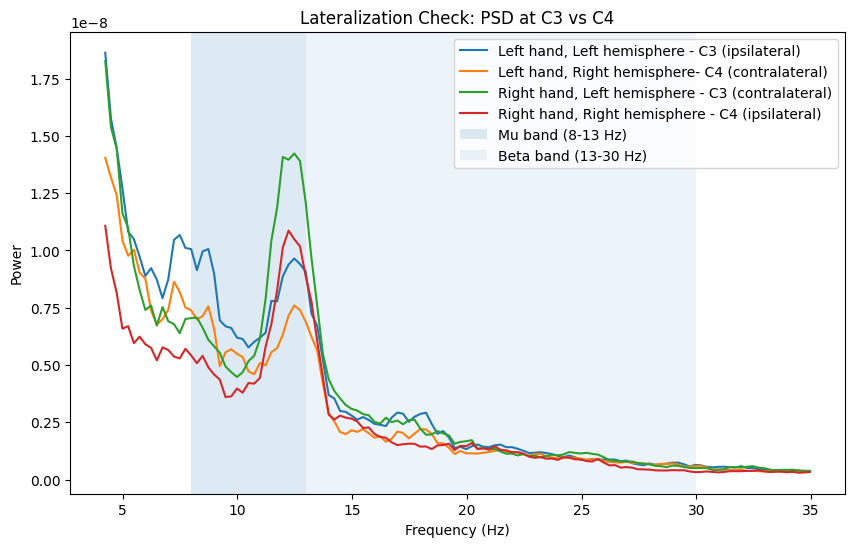

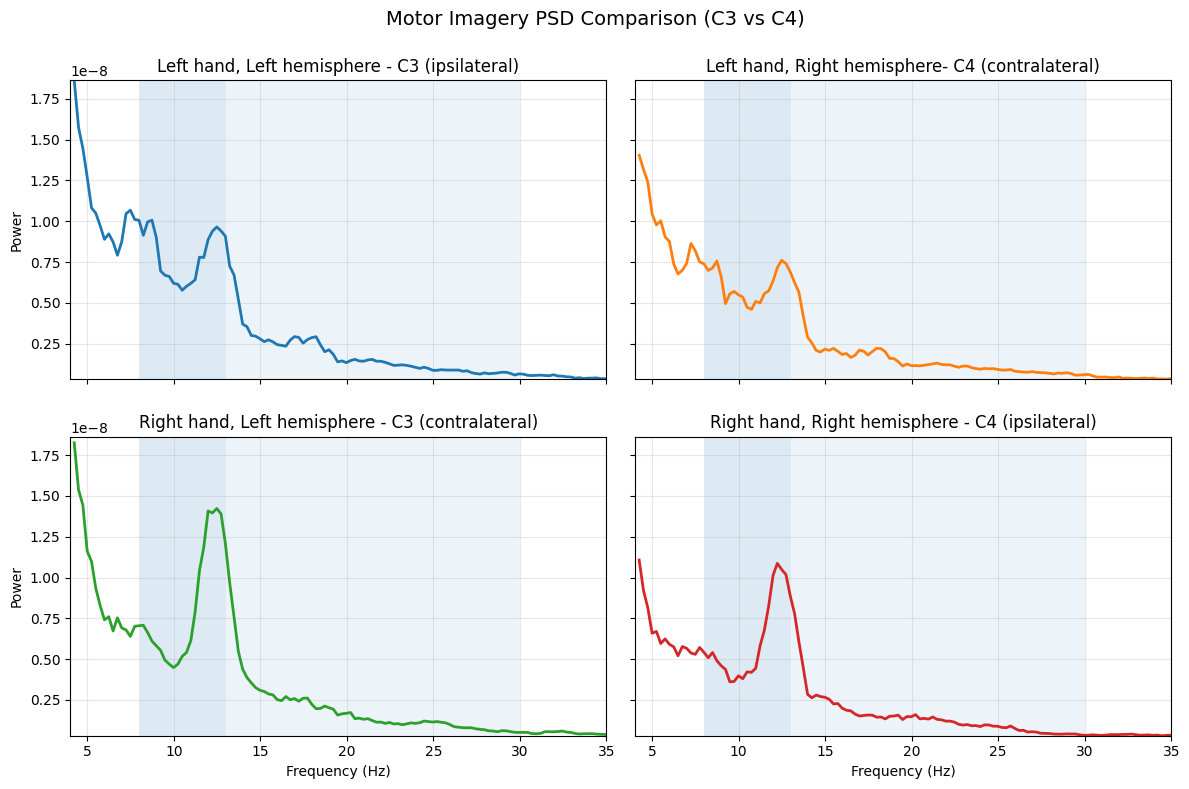

In [47]:
# Compute average PSD for C3 and C4 in each condition
c3_T1 = epochs_T1.copy().pick(['C3']).compute_psd(fmin=4, fmax=35).get_data().mean(axis=(0, 1))
c4_T1 = epochs_T1.copy().pick(['C4']).compute_psd(fmin=4, fmax=35).get_data().mean(axis=(0, 1))

c3_T2 = epochs_T2.copy().pick(['C3']).compute_psd(fmin=4, fmax=35).get_data().mean(axis=(0, 1))
c4_T2 = epochs_T2.copy().pick(['C4']).compute_psd(fmin=4, fmax=35).get_data().mean(axis=(0, 1))

freqs = epochs_T1.copy().pick(['C3']).compute_psd(fmin=4, fmax=35).freqs

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(freqs, c3_T1, label='Left hand, Left hemisphere - C3 (ipsilateral)')
ax.plot(freqs, c4_T1, label='Left hand, Right hemisphere- C4 (contralateral)')
ax.plot(freqs, c3_T2, label='Right hand, Left hemisphere - C3 (contralateral)')
ax.plot(freqs, c4_T2, label='Right hand, Right hemisphere - C4 (ipsilateral)')

ax.axvspan(8, 13, alpha=0.15, label='Mu band (8-13 Hz)')
ax.axvspan(13, 30, alpha=0.08, label='Beta band (13-30 Hz)')

ax.set_title('Lateralization Check: PSD at C3 vs C4')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power')
ax.legend(loc='upper right')
plt.show()

import numpy as np
import matplotlib.pyplot as plt

psd_dict = {
    "Left hand, Left hemisphere - C3 (ipsilateral)": (c3_T1, 'tab:blue'),
    "Left hand, Right hemisphere- C4 (contralateral)": (c4_T1, 'tab:orange'),
    "Right hand, Left hemisphere - C3 (contralateral)": (c3_T2, 'tab:green'),
    "Right hand, Right hemisphere - C4 (ipsilateral)": (c4_T2, 'tab:red')
}

ymin = min(np.min(v[0]) for v in psd_dict.values())
ymax = max(np.max(v[0]) for v in psd_dict.values())

fig, axes = plt.subplots(2,2, figsize=(12,8), sharex=True, sharey=True)

for ax, (title, (psd, color)) in zip(axes.ravel(), psd_dict.items()):

    ax.plot(freqs, psd, color=color, linewidth=2)

    ax.axvspan(8,13,alpha=0.15)
    ax.axvspan(13,30,alpha=0.08)

    ax.set_title(title)
    ax.set_xlim(4,35)
    ax.set_ylim(ymin,ymax)
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Frequency (Hz)")

for ax in axes[:,0]:
    ax.set_ylabel("Power")

plt.suptitle("Motor Imagery PSD Comparison (C3 vs C4)", fontsize=14)

plt.tight_layout()
plt.show()

## Time–Frequency Analysis (Morlet Wavelets)

We compute a time–frequency representation to visualize task-related power changes over time.
We use baseline normalization (-2 to -1 s) and log-ratio scaling.

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


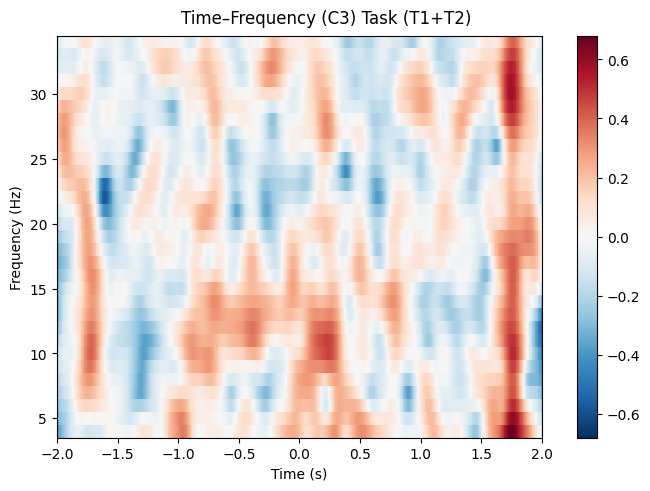

[<Figure size 640x480 with 2 Axes>]

In [48]:
power = mne.time_frequency.tfr_morlet(
    epochs_task.copy().pick(["C3"]),
    freqs=np.arange(4, 35, 1),
    n_cycles=np.arange(4, 35, 1) / 2,
    return_itc=False,
    average=True
)

power.plot(baseline=(-2, -1), mode="logratio", title="Time–Frequency (C3) Task (T1+T2)")